# Part 1
## (ii) Isotherm annealing: Analytical solution 

Result: plot of concentration vs distance and contration gradient vs distance 
Self diffusion of Ni* and Cu* tracer atoms in bars of Ni and Cu, respectively. 

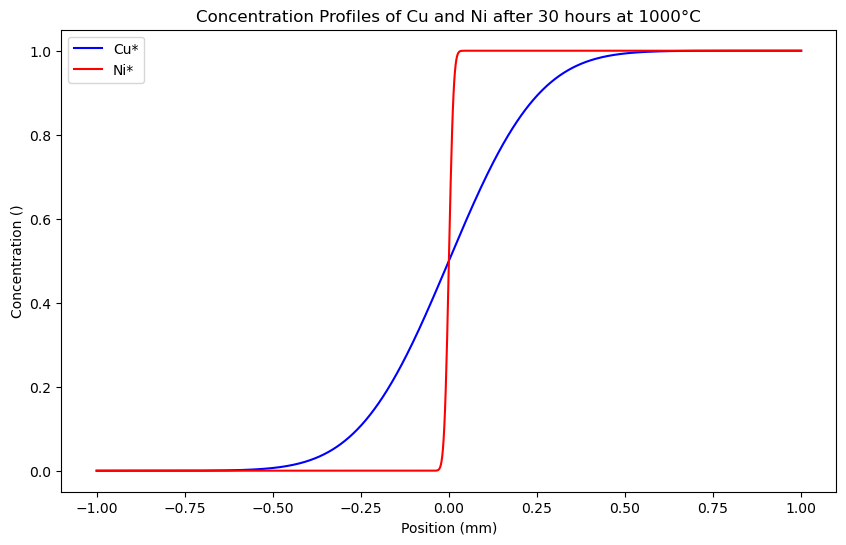

In [30]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math

# Problem parameters
T=1000+273.15 # K
t_tot=30*3600 # s
R=8.314 # J/mol*K
x = np.linspace(-1e-3, 1e-3, 1000) # m, i.e. from -1 mm to 1 mm

# Material parameters (experimental values from table 2.2 in Porter et al. Phase Transformations in Metals and Alloys)
D0_Cu=31e-6 # m^2/s
D0_Ni=150e-6 # m^2/s
Q_Cu=200.3 # kJ/mol
Q_Ni=279.7 # kJ/mol

# Diffusion coefficient function, D(T)
def Diff_coeff(T, D0, Q):
    return D0*np.exp(-Q*1000/(R*T))

D_Cu=Diff_coeff(T, D0_Cu, Q_Cu)
D_Ni=Diff_coeff(T, D0_Ni, Q_Ni)

# Concentration profile function, C(x,t)
def Concentration_profile(x, t, D, C1, C2):
    return (C1+C2)/2 - (C1-C2)/2 * math.erf(x/(2*np.sqrt(D*t)))

# Calculating concentration profiles for Cu and Ni, with inital condtion: 
# C(x,1)= 1 for x>0 and C(x,1)= 0 for x<0
C_Cu = []  
C_Ni = []

for xi in x:
    C_Cu.append(Concentration_profile(xi, t_tot, D_Cu, 0, 1))
    C_Ni.append(Concentration_profile(xi, t_tot, D_Ni, 0, 1))

# Plotting the concentration profiles
plt.figure(figsize=(10, 6))
plt.plot(x*1e3, C_Cu, label='Cu*', color='blue')
plt.plot(x*1e3, C_Ni, label='Ni*', color='red')
plt.title('Concentration Profiles of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)')     
plt.ylabel('Concentration ()')
plt.legend()
plt.legend()


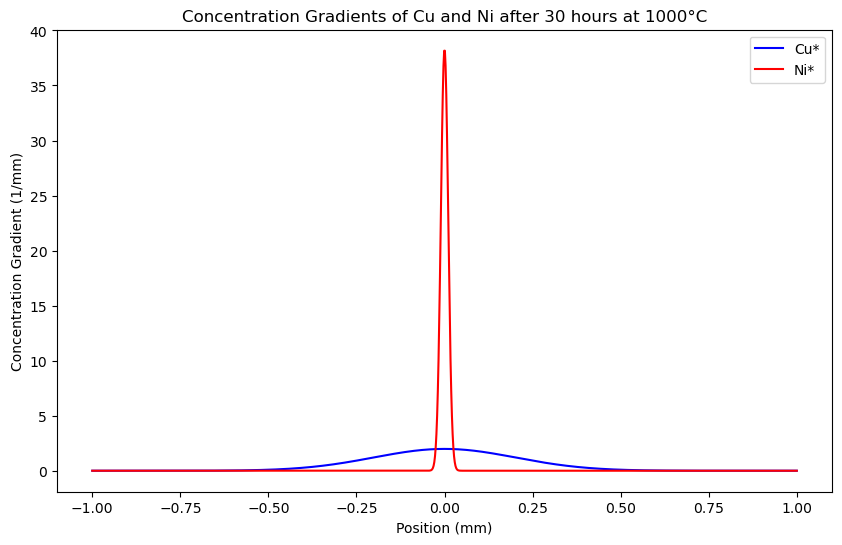

In [29]:
# Concetraion gradients
def Concentration_gradient(x, t, D, C1, C2):
    return -(C1-C2)/(2*np.sqrt(np.pi*D*t)) * np.exp(-x**2/(4*D*t))

Cons_Cu_grad = []
Cons_Ni_grad = []

for xi in x:
    Cons_Cu_grad.append(Concentration_gradient(xi, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm
    Cons_Ni_grad.append(Concentration_gradient(xi, t_tot, D_Ni, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm

plt.figure(figsize=(10, 6))
plt.plot(x*1e3, Cons_Cu_grad, label='Cu*', color='blue')
plt.plot(x*1e3, Cons_Ni_grad, label='Ni*', color='red')
plt.title('Concentration Gradients of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)') 
plt.ylabel('Concentration Gradient (1/mm)')
plt.legend()        

In [32]:
print(Concentration_gradient(0, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm

1.9819491252865742
